# 03 — Semi-Synthetic Benchmarks

**Goal:** Rigorously compare all seven panel estimators across four treatment patterns using *semi-synthetic* data derived from the [`basque`](https://en.wikipedia.org/wiki/Basque_Country_(autonomous_community)) dataset.

### What is a semi-synthetic experiment?

A fully synthetic experiment generates both the outcome panel *and* the treatment mask from scratch, so results depend on the DGP assumptions.  
A semi-synthetic experiment instead:

1. **Extracts a clean baseline M** from real data (never-treated rows or pre-treatment columns).
2. **Draws a synthetic treatment mask Z** from a chosen pattern.
3. **Injects a known effect $\tau^*$** — so we know the ground truth.
4. **Runs each estimator** and measures recovery: $\text{error} = |\tau^* - \hat{\tau}| / |\tau^*|$.

Because the baseline comes from real data, confounding structure is realistic; because $\tau^*$ is injected, evaluation is exact.

## Treatment patterns and estimator support

Not every estimator is valid under every pattern — the table below shows which combinations are benchmarked.

| Pattern | Description | Supported estimators |
|:---:|:---|:---|
| **IID** | Each (unit, period) cell independently treated with prob 0.2 | DC-PR, MC-NNM, CovPCA |
| **Block** | A random contiguous block of units × periods is treated | DC-PR, MC-NNM, CovPCA, DID, SDID, SC, RSC |
| **Staggered** | Units adopt treatment at different randomly drawn times | DC-PR, MC-NNM, CovPCA, DID, SDID, SC, RSC |
| **Adaptive** | Treatment triggers when a unit's outcome falls below a lookback minimum | DC-PR, MC-NNM, CovPCA |

Method keys used internally by `run_experiment`:

| Key | Class |
|:---|:---|
| `DC_PR_auto_rank` | `DCPanelSolver` |
| `MC_NNM_CV` | `MCNNMPanelSolver` (with cross-validation) |
| `CovariancePCA` | `CovariancePCAPanelSolver` |
| `DID` | `DIDPanelSolver` |
| `SDID` | `SDIDPanelSolver` |
| `SC` | `OLSSCPanelSolver` |
| `RobustSyntheticControl` | `RSCPanelSolver` |

In [1]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
from IPython.display import display

from causaltensor.datasets import PanelDataset
import matplotlib.pyplot as plt

from causaltensor.semi_synthetic import (
    plot_aa_null_figure,
    plot_empirical_power_figure,
    run_aa_test,
    run_empirical_power_grid,
    run_experiment,
)

# Canonical display order for methods and patterns
METHODS_ORDER  = ["DC_PR_auto_rank", "MC_NNM_CV", "CovariancePCA", "DID", "SDID", "SC", "RobustSyntheticControl"]
PATTERNS_ORDER = ["IID", "Block", "Staggered", "Adaptive"]

---
## Step 1 — Dataset overview

In [2]:
dataset_name = "basque"
panel = PanelDataset.from_builtin(dataset_name)

O = panel.O   # (N, T) float array
Z = panel.Z   # (N, T) binary treatment mask

print(f"Dataset : {dataset_name!r}")
print(f"Shape   : {O.shape[0]} units × {O.shape[1]} periods")
print(f"Years   : {int(panel.time_index[0])} – {int(panel.time_index[-1])}")
treated_mask = Z.any(axis=1)
print(f"Treated : {list(panel.unit_index[treated_mask])}")
print(f"Control : {(~treated_mask).sum()} never-treated units (baseline pool)")

Dataset : 'basque'
Shape   : 18 units × 43 periods
Years   : 1955 – 1997
Treated : ['Basque Country (Pais Vasco)']
Control : 17 never-treated units (baseline pool)


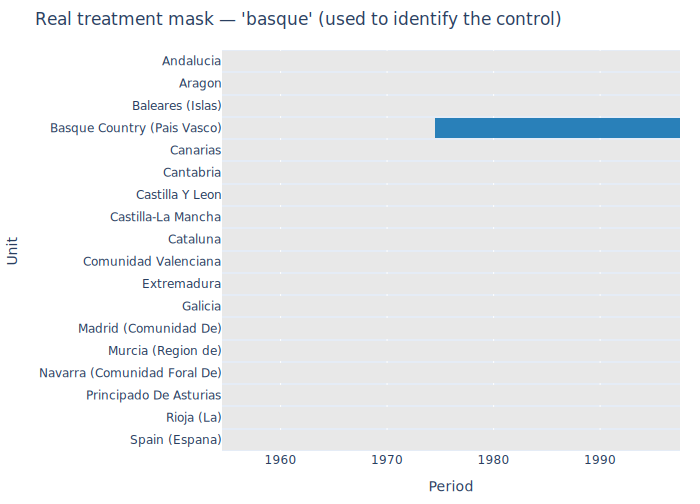

In [ ]:
# Real treatment mask — the semi-synthetic experiment replaces this with synthetic Z
Z_hot = pd.DataFrame(Z * 1.0, index=panel.unit_index, columns=panel.time_index.astype(int))
fig = px.imshow(
    Z_hot,
    color_continuous_scale=["#e8e8e8", "#2980b9"],
    zmin=0, zmax=1,
    labels={"x": "Period", "y": "Unit", "color": "Treated"},
    title=f"Real treatment mask — {dataset_name!r}  (used to identify the control)",
    aspect="auto",
)
fig.update_coloraxes(showscale=False)
fig.update_traces(ygap=2)  # visible separator between rows
fig.update_layout(height=max(500, Z.shape[0] * 28), margin=dict(l=160, r=20, t=50, b=40))
fig.show("svg")  # remove "svg" to make the chart interactive

---
## Step 2 — Semi-synthetic experiment

`run_experiment` builds the control-rows baseline `M`, then for each `(treatment_level, pattern, trial)` triple:
- draws a fresh synthetic `Z_syn`,
- injects `tau_star = treatment_level × mean(|M|)` into `M`,
- runs all valid estimators and records `tau_hat` and `error`.

Increase `N_TRIALS` (e.g. to 50) for tighter confidence bands.

In [ ]:
N_TRIALS         = 10              # increase for better estimates
TREATMENT_LEVELS = [0.05, 0.1, 0.2] # fractions of mean(|M|) injected as tau_star

print("Running semi-synthetic experiment...")
df_exp = run_experiment(
    O, Z,
    treatment_levels=TREATMENT_LEVELS,
    n_trials=N_TRIALS,
    seed=42,
    verbose=False,
)
print(f"Done — {len(df_exp):,} rows ({df_exp['method'].nunique()} methods × "
      f"{df_exp['pattern'].nunique()} patterns × "
      f"{df_exp['treatment_level'].nunique()} levels × {N_TRIALS} trials)")
display(df_exp.head(10))

Running semi-synthetic experiment...


C:\Users\arush\MIT Dropbox\Arushi Jain\RA\Panel Inference\causaltensor\src\causaltensor\cauest\MCNNM.py:249: RuntimeWarning: invalid value encountered in scalar divide
  return np.sum((valid_Ω)*((O-res.baseline)**2)) / np.sum(valid_Ω)


Done — 540 rows (7 methods × 4 patterns × 3 levels × 10 trials)


,method,pattern,treatment_level,trial,tau_star,tau_hat,error
0,DC_PR_auto_rank,IID,0.05,0,0.266048,0.154974,0.417498
1,MC_NNM_CV,IID,0.05,0,0.266048,0.234059,0.120239
2,CovariancePCA,IID,0.05,0,0.266048,0.048571,0.817435
3,DC_PR_auto_rank,IID,0.05,1,0.266048,0.294099,0.105434
4,MC_NNM_CV,IID,0.05,1,0.266048,0.272176,0.023032
5,CovariancePCA,IID,0.05,1,0.266048,0.345580,0.298939
6,DC_PR_auto_rank,IID,0.05,2,0.266048,0.244367,0.081493
7,MC_NNM_CV,IID,0.05,2,0.266048,0.299873,0.127139
8,CovariancePCA,IID,0.05,2,0.266048,0.269133,0.011596
9,DC_PR_auto_rank,IID,0.05,3,0.266048,0.279292,0.049779


### 2a — Mean error summary

$\text{error} = |\tau^* - \hat{\tau}| / |\tau^*|$.  Lower is better.  Grey cells = combination not benchmarked.

In [ ]:
sub02 = df_exp[df_exp["treatment_level"] == 0.1]

pivot_err = (
    sub02
    .groupby(["method", "pattern"])["error"]
    .mean()
    .unstack("pattern")
    .reindex(index=METHODS_ORDER, columns=PATTERNS_ORDER)
)
print("Mean relative error  |tau* − tau_hat| / |tau*|   (treatment_level = 0.1)")
display(pivot_err.round(3))

Mean relative error  |tau* − tau_hat| / |tau*|   (treatment_level = 0.1)


pattern,IID,Block,Staggered,Adaptive
method,,,,
DC_PR_auto_rank,0.101,0.713,0.620,0.307
MC_NNM_CV,0.028,0.585,0.520,0.235
CovariancePCA,0.104,3.320,3.158,1.116
DID,NaN,0.880,0.811,NaN
SDID,NaN,0.434,0.280,NaN
SC,NaN,0.534,NaN,NaN
RobustSyntheticControl,NaN,0.607,NaN,NaN


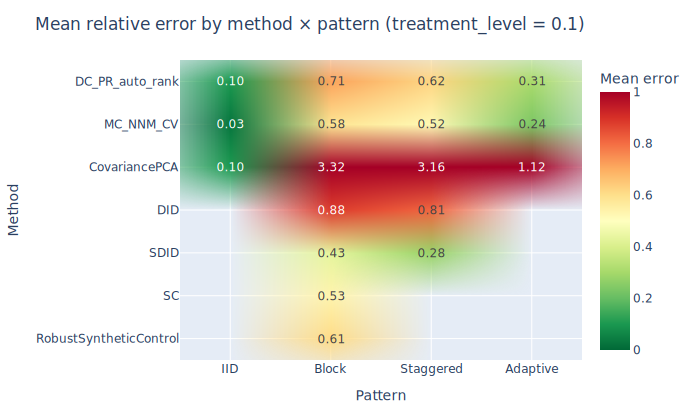

In [ ]:
import plotly.graph_objects as go

z_vals = pivot_err.values

# Build annotation text (show value or blank for NaN)
text_vals = [
    [f"{v:.2f}" if not np.isnan(v) else "" for v in row]
    for row in z_vals
]

fig = go.Figure(go.Heatmap(
    z=z_vals,
    x=PATTERNS_ORDER,
    y=METHODS_ORDER,
    text=text_vals,
    texttemplate="%{text}",
    colorscale="RdYlGn_r",
    zmin=0, zmax=1,
    colorbar=dict(title="Mean error"),
))
fig.update_layout(
    title="Mean relative error by method × pattern  (treatment_level = 0.1)",
    xaxis_title="Pattern",
    yaxis_title="Method",
    height=420,
    margin=dict(l=180, r=60, t=60, b=60),
    yaxis=dict(autorange="reversed"),
)
fig.show("svg")  # remove "svg" to make the chart interactive

### 2b — Error distribution by pattern (treatment level = 0.1)

Box plots show the spread of relative error across the 10 trials for each estimator.

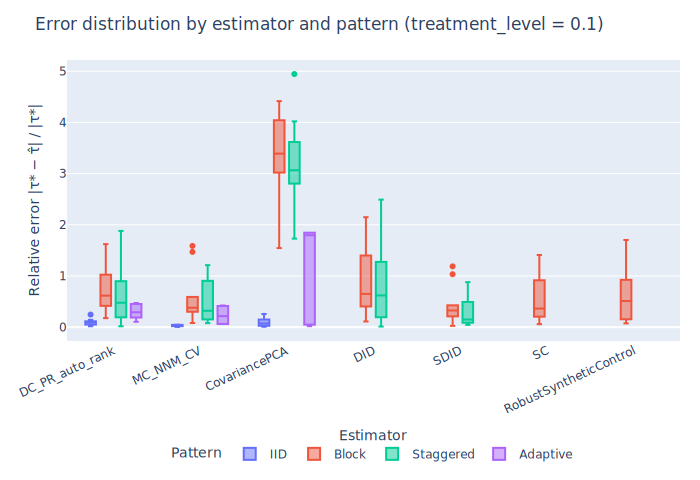

In [ ]:
fig = px.box(
    sub02.dropna(subset=["error"]),
    x="method",
    y="error",
    color="pattern",
    category_orders={"method": METHODS_ORDER, "pattern": PATTERNS_ORDER},
    labels={"error": "Relative error  |τ* − τ̂| / |τ*|", "method": "Estimator", "pattern": "Pattern"},
    title="Error distribution by estimator and pattern  (treatment_level = 0.1)",
)
fig.update_layout(
    height=480,
    xaxis_tickangle=-25,
    margin=dict(l=60, r=20, t=60, b=120),
    legend=dict(title="Pattern", orientation="h", y=-0.35, x=0.5, xanchor="center"),
)
fig.show("svg")  # remove "svg" to make the chart interactive

### 2c — Effect size vs. accuracy

Smaller treatment levels (weak signals) make estimation harder.  
This chart shows mean error across all valid patterns as treatment level varies.

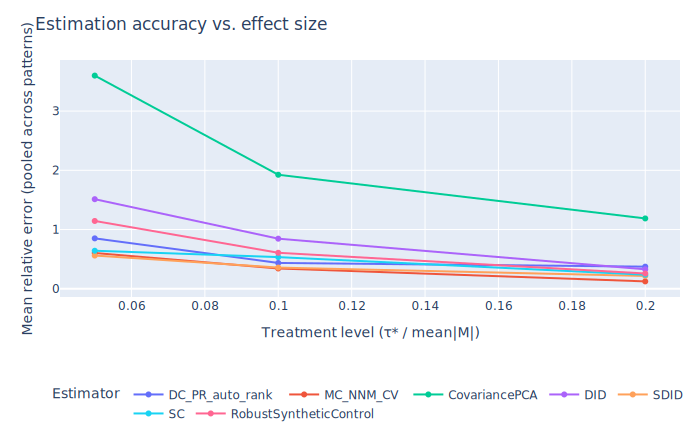

In [ ]:
tl_df = (
    df_exp
    .groupby(["method", "treatment_level"])["error"]
    .mean()
    .reset_index()
)

fig = px.line(
    tl_df,
    x="treatment_level",
    y="error",
    color="method",
    markers=True,
    category_orders={"method": METHODS_ORDER},
    labels={
        "treatment_level": "Treatment level  (τ* / mean|M|)",
        "error": "Mean relative error  (pooled across patterns)",
        "method": "Estimator",
    },
    title="Estimation accuracy vs. effect size",
)
fig.update_layout(
    height=440,
    margin=dict(l=60, r=20, t=60, b=100),
    legend=dict(orientation="h", y=-0.35, x=0.5, xanchor="center", title="Estimator"),
)
fig.show("svg")  # remove "svg" to make the chart interactive

---
## Step 3 — A/A null calibration and empirical power

**Null (left-style figure).** Keep the clean baseline `M` (true effect 0), draw many random synthetic assignment masks `Z_syn`, and record $\hat\tau$ each time. That gives the *sampling distribution* of the estimator under $H_0{:}\,\tau=0$ for this panel and pattern.

**Test rule.** From those null draws, take $c$ as the $(1-\alpha)$ quantile of $|\hat\tau|$ (we use $\alpha=0.05$). By construction, roughly 5% of null draws have $|\hat\tau|>c$ — this fixes the *size* of the two-sided rule "reject if $|\hat\tau|>c$".

**Power (right-style figure).** Inject a *relative* effect on treated cells: $O = M + \delta\,\mathrm{mean}(|M|)\,Z_{\mathrm{syn}}$, re-run the estimator, and count how often $|\hat\tau|>c$. That fraction is **empirical power** at effect level $\delta$ (standard definition: power $= P(\text{reject}\mid H_1)$; here $H_1$ is encoded by $\delta>0$).

Increase `N_AA_NULL` and `N_AA_POWER` for smoother curves (more compute).

In [3]:
N_AA_NULL = max(40, N_TRIALS)  # null quantiles need enough Monte Carlo draws

print("Running A/A null simulations...")
df_aa = run_aa_test(
    O, Z,
    n_trials=N_AA_NULL,
    seed=42,
    verbose=False,
)
print(f"Done — {len(df_aa):,} rows (tau_hat under H0, no injection)")
display(df_aa.head(10))

null_summary = (
    df_aa.groupby(["method", "pattern"])["tau_hat"]
    .agg(mean="mean", std="std", n="count")
    .reindex(index=pd.MultiIndex.from_product([METHODS_ORDER, PATTERNS_ORDER], names=["method", "pattern"]))
)
display(null_summary.round(4))

Running A/A null simulations...
Done — 200 rows (tau_hat under H0, no injection)


,method,pattern,baseline_type,trial,tau_hat,std_M
0,DC_PR_auto_rank,IID,control,0,-0.110051,2.248228
1,MC_NNM_CV,IID,control,0,-0.031989,2.248228
2,CovariancePCA,IID,control,0,-0.217477,2.248228
3,DC_PR_auto_rank,IID,control,1,0.009056,2.248228
4,MC_NNM_CV,IID,control,1,0.015929,2.248228
5,CovariancePCA,IID,control,1,0.055009,2.248228
6,DC_PR_auto_rank,IID,control,2,-0.020940,2.248228
7,MC_NNM_CV,IID,control,2,-0.004299,2.248228
8,CovariancePCA,IID,control,2,0.007087,2.248228
9,DC_PR_auto_rank,IID,control,3,-0.019394,2.248228


mean     std     n
method                 pattern                        
DC_PR_auto_rank        IID       -0.0249  0.0375  10.0
                       Block      0.1526  0.3011  10.0
                       Staggered  0.1673  0.4325  10.0
                       Adaptive  -0.1695  0.0868  10.0
MC_NNM_CV              IID       -0.0053  0.0222  10.0
                       Block      0.0336  0.4595  10.0
                       Staggered -0.0159  0.2741  10.0
                       Adaptive  -0.1640  0.0824  10.0
CovariancePCA          IID        0.0159  0.1109  10.0
                       Block      2.6015  1.8428  10.0
                       Staggered  1.3774  0.7137  10.0
                       Adaptive   0.3677  0.5129  10.0
DID                    IID           NaN     NaN   NaN
                       Block      0.0546  0.6076  10.0
                       Staggered -0.0264  0.5752  10.0
                       Adaptive      NaN     NaN   NaN
SDID                   IID           NaN     NaN   NaN
                       Block     -0.0893  0.1767  10.0
                       Staggered  0.0245  0.0867  10.0
                       Adaptive      NaN     NaN   NaN
SC                     IID           NaN     NaN   NaN
                       Block      0.0284  0.3991  10.0
                       Staggered -0.0169  0.1723  10.0
                       Adaptive      NaN     NaN   NaN
RobustSyntheticControl IID           NaN     NaN   NaN
                       Block     -0.0778  0.3161  10.0
                       Staggered -0.0194  0.0852  10.0
                       Adaptive      NaN     NaN   NaN

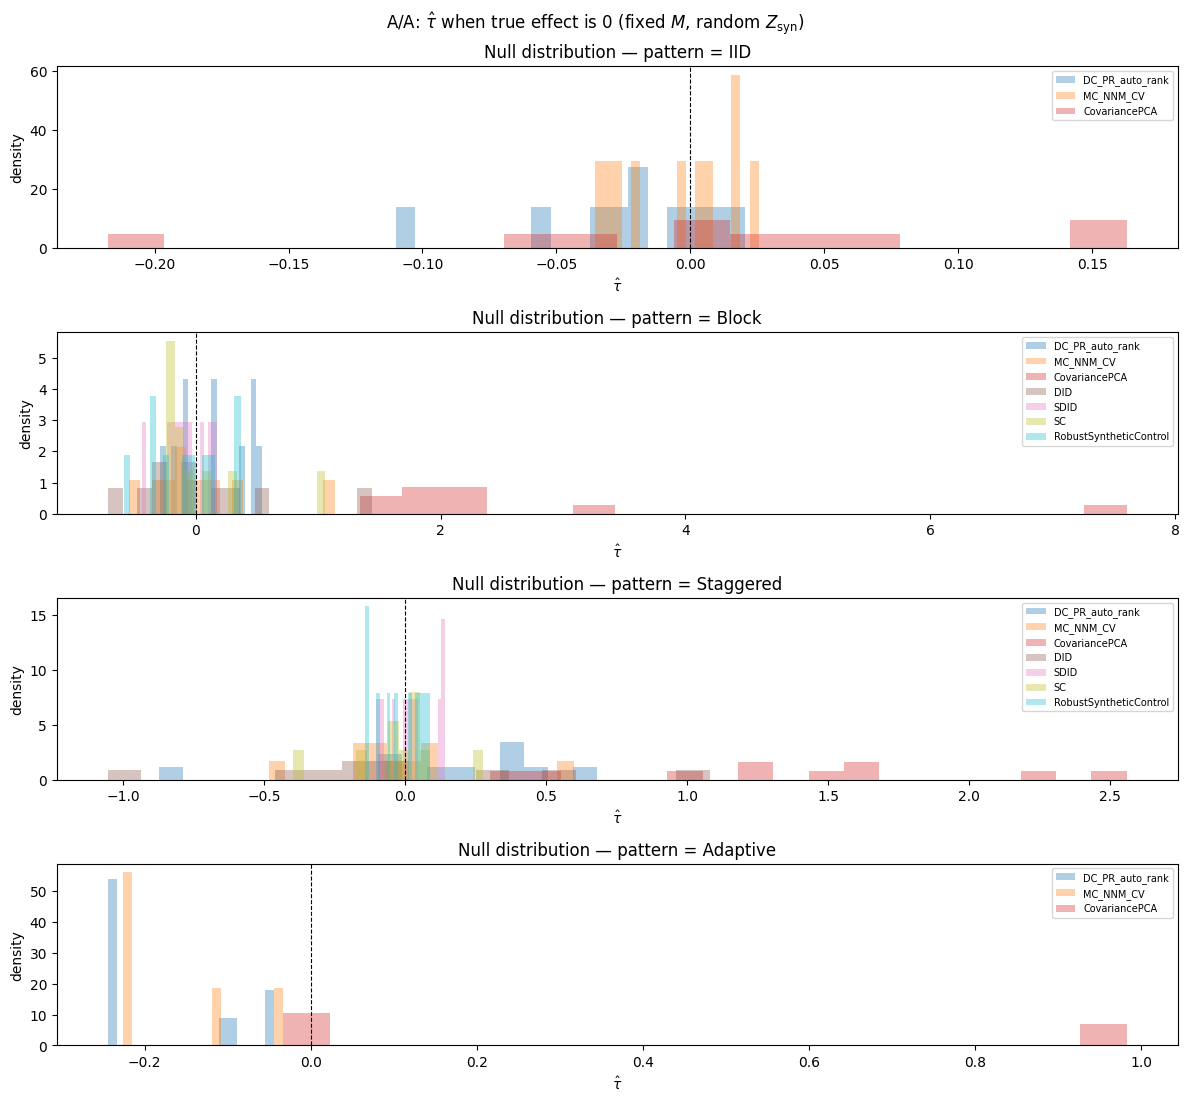

In [4]:
# Null: distribution of tau_hat (one subplot per pattern; overlaid histograms per method)
fig_null, _ = plot_aa_null_figure(df_aa, bins=18)
plt.show()

Running power Monte Carlo (this may take a minute)...
Done — 56 power rows


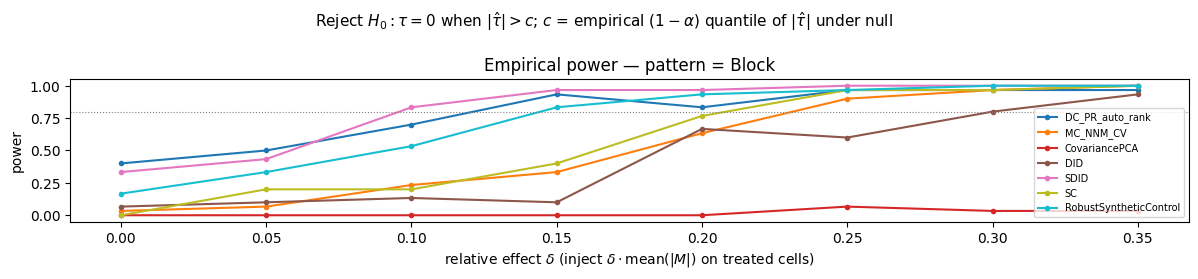

In [7]:
# Power curves: reject H0 when |tau_hat| > c, with c from null draws (alpha=0.05)
REL_EFFECTS = np.linspace(0.0, 0.35, 8)
N_AA_POWER = 30 # Increase

print("Running power Monte Carlo (this may take a while)...")
_, df_power = run_empirical_power_grid(
    O, Z, df_aa,
    REL_EFFECTS,
    alpha=0.05,
    n_trials_per_effect=N_AA_POWER,
    patterns=["Block"],
    seed=43,
    verbose=False,
)
print(f"Done — {len(df_power):,} power rows")

fig_power, _ = plot_empirical_power_figure(df_power)
plt.show()

---
## Summary

| What we learned | |
|:---|:---|
| **Best all-around** | DC-PR and MC-NNM tend to be competitive across all four patterns. |
| **Pattern specialization** | SC and RSC are restricted to Block/Staggered patterns; DID/SDID break under IID or Adaptive. |
| **Effect size matters** | All methods improve as the injected effect grows relative to outcome noise. |
| **A/A calibration** | Under $H_0$, $\hat\tau$ should cluster near 0; empirical thresholds on $|\hat\tau|$ link null spread to power vs injected $\delta$. |
